In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter
import random

import importlib
import model as md
import view as vw
from tqdm import tqdm

importlib.reload(md)
importlib.reload(vw)

from model.relevant_methods import phase_methods

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Local_analysis\..


In [2]:
phase_method=md.get_phase_SWFR

In [3]:
F=400e3
gen_unstable=0.1
duration_T=60
phase_real=50
bits=12
SNR=60
T=1/F

estimated_diff_range=[]
fs_mult_range=[]
for fs_mult in range (3,150,1):
    fs_mult_range.append(fs_mult)
    estimated_diff_range_series=[]

    for i in range(0,50,1):

        fs = F * fs_mult
        duration = duration_T * T

        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        U = md.add_SNR(U, SNR)
        I = md.add_SNR(I, SNR)

        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)

        phase_estimated = phase_method(t, U, I, F)
        err_deg = abs(abs(phase_real) - abs(phase_estimated))
        estimated_diff_range_series.append(err_deg)

    estimated_diff_range_series_mid_value=np.mean(estimated_diff_range_series)

    estimated_diff_range.append(estimated_diff_range_series_mid_value)

In [4]:
from scipy.optimize import curve_fit
import matplotlib.ticker as ticker

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

def fit_and_plot_exponential(x_data, y_data, x_label):
    x_data = np.array(x_data)
    y_data = np.array(y_data)

    def exp_decay(x, A, B, C):
        return A * np.exp(-B * x) + C

    p0 = [max(y_data) - min(y_data), 0.1, min(y_data)]

    try:
        popt, _ = curve_fit(exp_decay, x_data, y_data, p0=p0, maxfev=5000)
    except RuntimeError:
        return None
    
    A, B, C = popt
    x_min = np.min(x_data)
    fraction = 0.03
    x_sat = x_min - np.log(fraction) / B

    # Визуализация
    plt.figure(figsize=(6, 5))
    
    dot_color = '#7fb3d5'
    line_color = '#1f618d'
    sat_line_color = '#6c3483'

    plt.scatter(x_data, y_data, color=dot_color, alpha=0.6, s=15, label='Экспериментальные данные')

    x_dense = np.linspace(x_min, np.max(x_data), 1000)
    plt.plot(x_dense, exp_decay(x_dense, *popt), color=line_color, linewidth=2, label='Аппроксимация')

    if x_min <= x_sat <= np.max(x_data):
        plt.axvline(x=x_sat, color=sat_line_color, linestyle='--', linewidth=1.5, 
                    label=f'Точка насыщения ({x_sat:.1f})')

    # --- НАСТРОЙКА ОСИ Y (НАУЧНЫЙ ФОРМАТ) ---
    plt.yscale('log')
    ax = plt.gca()

    # Создаем форматтер: научная нотация для ВСЕХ делений
    # labelOnlyBase=False подписывает промежуточные деления (2, 3, 4...)
    # minor_thresholds отключает автоматическое переключение на обычные числа
    y_formatter = ticker.LogFormatterSciNotation(labelOnlyBase=False, minor_thresholds=(np.inf, np.inf))
    
    ax.yaxis.set_major_formatter(y_formatter)
    ax.yaxis.set_minor_formatter(y_formatter)

    plt.grid(True, which="both", linestyle=':', alpha=0.6)

    plt.xlabel(x_label)
    plt.ylabel('Отклонение °.')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

    return popt, x_sat

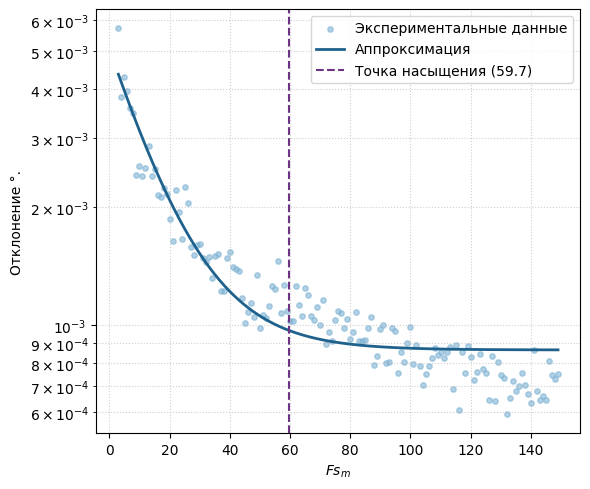

(array([0.00421657, 0.06187364, 0.00086539]), np.float64(59.67288440427118))

In [54]:
fit_and_plot_exponential(fs_mult_range,estimated_diff_range,"$Fs_m$")

In [55]:
F=400e3
gen_unstable=0.1
fs_mult=60
phase_real=50
bits=12
SNR=60
T=1/F

diff_dt=[]
dt_range=[]
for duration_T in range (3,150,1):
    dt_range.append(duration_T)
    diff_dt_series=[]

    for i in range(0,50,1):

        fs = F * fs_mult
        duration = duration_T * T

        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        U = md.add_SNR(U, SNR)
        I = md.add_SNR(I, SNR)

        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)

        phase_estimated = phase_method(t, U, I, F)
        err_deg = abs(abs(phase_real) - abs(phase_estimated))
        diff_dt_series.append(err_deg)

    diff_dt_series_mid_value=np.mean(diff_dt_series)

    diff_dt.append(diff_dt_series_mid_value)

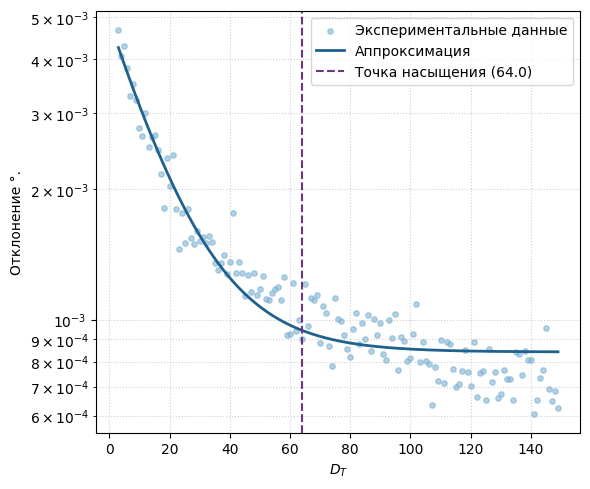

(array([0.00405828, 0.05745879, 0.00084187]), np.float64(64.02735716787375))

In [56]:
fit_and_plot_exponential(dt_range,diff_dt,"$D_T$")

In [9]:
F=400e3
gen_unstable=0.1
fs_mult=80
phase_real=50
duration_T=80
SNR=60
T=1/F

diff_bit=[]
bit_range=[]
for bits in range (6,36,1):

    bit_range.append(bits)
    diff_bit_series=[]

    for i in range(0,50,1):

        fs = F * fs_mult
        duration = duration_T * T

        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        U = md.add_SNR(U, SNR)
        I = md.add_SNR(I, SNR)

        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)

        phase_estimated = phase_method(t, U, I, F)
        err_deg = abs(abs(phase_real) - abs(phase_estimated))
        diff_bit_series.append(err_deg)

    diff_bit_series_mid_value=np.mean(diff_bit_series)

    diff_bit.append(diff_bit_series_mid_value)

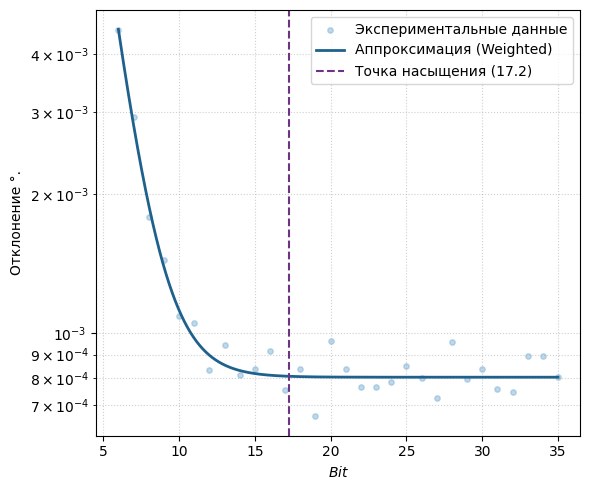

(array([0.14921424, 0.61503926, 0.00080421]),
 np.float64(0.9905961584207491),
 np.float64(17.231405413547996))

In [48]:
fit_and_plot_exponential(bit_range,diff_bit,"$Bit$")

In [51]:
F=400e3
gen_unstable=0.1
fs_mult=60
phase_real=50
duration_T=60
bits=12
T=1/F

diff_SNR=[]
SNR_range=[]
for SNR in range(30,150,1):
    SNR_range.append(SNR)
    diff_SNR_series=[]
    
    for i in range(0,50,1):

        fs = F * fs_mult
        duration = duration_T * T

        t = np.linspace(0, duration, int(duration * fs))

        phase = md.generate_common_phase(
            t,
            F,
            gen_unstable,
            phase0_deg=0
        )

        U, I = md.generate_signals_from_phase(
            phase,
            phase_diff_deg=phase_real
        )

        U = md.add_SNR(U, SNR)
        I = md.add_SNR(I, SNR)

        U = md.adc_quantize(U, int(bits), 1)
        I = md.adc_quantize(I, int(bits), 1)

        phase_estimated = phase_method(t, U, I, F)
        err_deg = abs(abs(phase_real) - abs(phase_estimated))
        diff_SNR_series.append(err_deg)

    diff_SNR.append(np.mean(diff_SNR_series))
    

In [46]:
def fit_and_plot_exponential(x_data, y_data, x_label):
    x_data, y_data = np.array(x_data), np.array(y_data)

    def exp_decay(x, A, B, C):
        return A * np.exp(-B * x) + C

    p0 = [np.max(y_data) - np.min(y_data), 0.1, np.min(y_data)]
    try:
        popt, _ = curve_fit(exp_decay, x_data, y_data, p0=p0, sigma=y_data, absolute_sigma=False, maxfev=10000)
    except: return None
    
    A, B, C = popt
    y_pred = exp_decay(x_data, *popt)
    r_squared = 1 - (np.sum((y_data - y_pred)**2) / np.sum((y_data - np.mean(y_data))**2))
    x_sat = np.min(x_data) - np.log(0.001) / B

    plt.figure(figsize=(6, 5))
    plt.scatter(x_data, y_data, color='#7fb3d5', alpha=0.5, s=15, label='Экспериментальные данные')
    x_dense = np.linspace(np.min(x_data), np.max(x_data), 1000)
    plt.plot(x_dense, exp_decay(x_dense, *popt), color='#1f618d', linewidth=2, label='Аппроксимация (Weighted)')

    if np.min(x_data) <= x_sat <= np.max(x_data):
        plt.axvline(x=x_sat, color='#6c3483', linestyle='--', linewidth=1.5, label=f'Точка насыщения ({x_sat:.1f})')

    # Настройка Y
    plt.yscale('log')
    ax = plt.gca()
    num_decades = np.log10(np.max(y_data)) - np.log10(np.min(y_data))
    
    if num_decades > 1.8:
        fmt = ticker.LogFormatterSciNotation(labelOnlyBase=True)
        ax.yaxis.set_minor_formatter(ticker.NullFormatter()) # Совсем скрываем мелкие подписи
    else:
        fmt = ticker.LogFormatterSciNotation(labelOnlyBase=False, minor_thresholds=(np.inf, np.inf))
        ax.yaxis.set_minor_formatter(fmt)

    ax.yaxis.set_major_formatter(fmt)
    plt.grid(True, which="both", linestyle=':', alpha=0.3 if num_decades > 1.8 else 0.6)

    plt.xlabel(x_label); plt.ylabel('Отклонение °.'); plt.legend(); plt.tight_layout(); plt.show()
    return popt, r_squared, x_sat

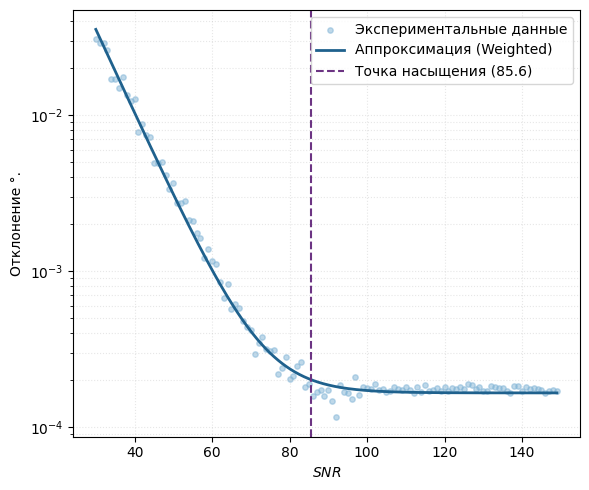

(array([1.46332275e+00, 1.24170238e-01, 1.65240160e-04]),
 np.float64(0.9821581934581438),
 np.float64(85.63132818089073))

In [52]:
fit_and_plot_exponential(SNR_range,diff_SNR,"$SNR$")